# **ASSIGNMENT** **9**

Name - Ayush Pathak

Roll no - 60

Batch - 03

Problem Statement : Clustering


1. Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2. Upload Dataset in Colab

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [ ]:
dataset = pd.read_csv('Mall_Customers.csv')
dataset.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


3. Explore the Dataset

In [ ]:
# Display basic information
dataset.info()

# Check for missing values
dataset.isnull().sum()

# Describe dataset
dataset.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


4. Select Features for Clustering

In [ ]:
# Selecting two important features
X = dataset.iloc[:, [3,4]].values

print(X[:10])

[[15 39]
 [15 81]
 [16  6]
 [16 77]
 [17 40]
 [17 76]
 [18  6]
 [18 94]
 [19  3]
 [19 72]]


5. Visualize Data

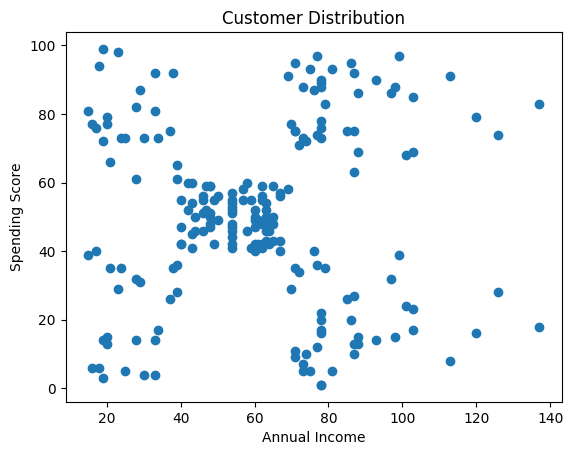

In [ ]:
plt.scatter(dataset['Annual Income (k$)'], dataset['Spending Score (1-100)'])
plt.title("Customer Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

6. Find Optimal Clusters (Elbow Method)

In [ ]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

Plotting the elbow graph

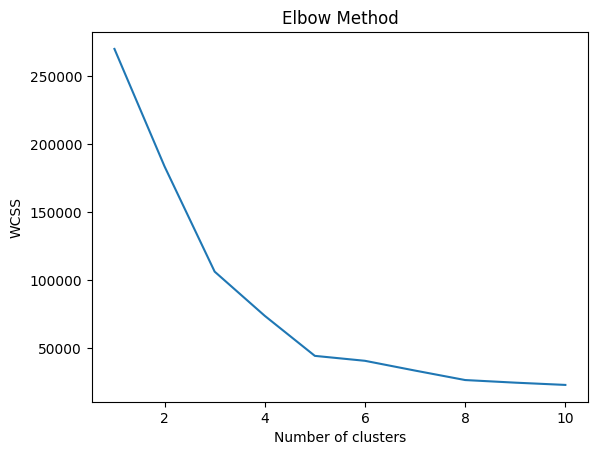

In [ ]:
plt.plot(range(1,11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

7. Train K-Means Model

In [ ]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)

y_kmeans = kmeans.fit_predict(X)

8. Visualize Clusters

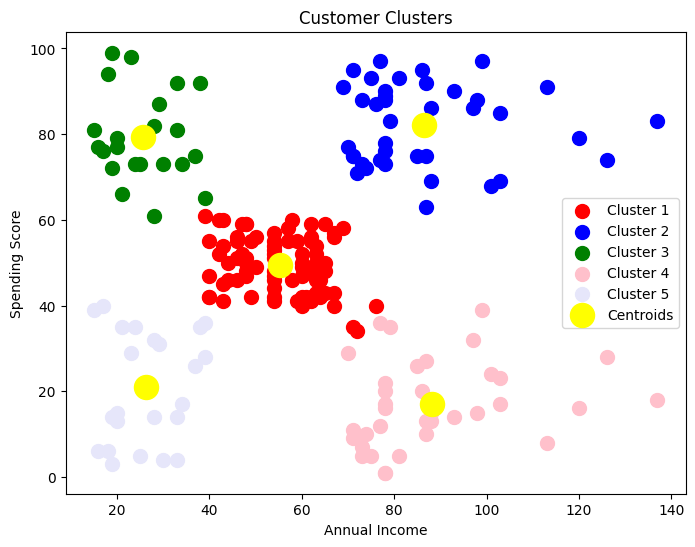

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(X[y_kmeans == 0,0], X[y_kmeans == 0,1], s=100, c='red', label='Cluster 1')
plt.scatter(X[y_kmeans == 1,0], X[y_kmeans == 1,1], s=100, c='blue', label='Cluster 2')
plt.scatter(X[y_kmeans == 2,0], X[y_kmeans == 2,1], s=100, c='green', label='Cluster 3')
plt.scatter(X[y_kmeans == 3,0], X[y_kmeans == 3,1], s=100, c='pink', label='Cluster 4')
plt.scatter(X[y_kmeans == 4,0], X[y_kmeans == 4,1], s=100, c='lavender', label='Cluster 5')

# Centroids
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            s=300, c='yellow', label='Centroids')

plt.title('Customer Clusters')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

9. Importing silhouette score


In [ ]:
from sklearn.metrics import silhouette_score

10. Calculate score for different K

In [ ]:
silhouette_scores = []

for i in range(2,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

    print(f"For n_clusters = {i}, Silhouette Score = {score:.4f}")

For n_clusters = 2, Silhouette Score = 0.3956
For n_clusters = 3, Silhouette Score = 0.4676
For n_clusters = 4, Silhouette Score = 0.4938
For n_clusters = 5, Silhouette Score = 0.5539
For n_clusters = 6, Silhouette Score = 0.5128
For n_clusters = 7, Silhouette Score = 0.5017
For n_clusters = 8, Silhouette Score = 0.4963
For n_clusters = 9, Silhouette Score = 0.4559
For n_clusters = 10, Silhouette Score = 0.4426


11. Plot Silhouette score

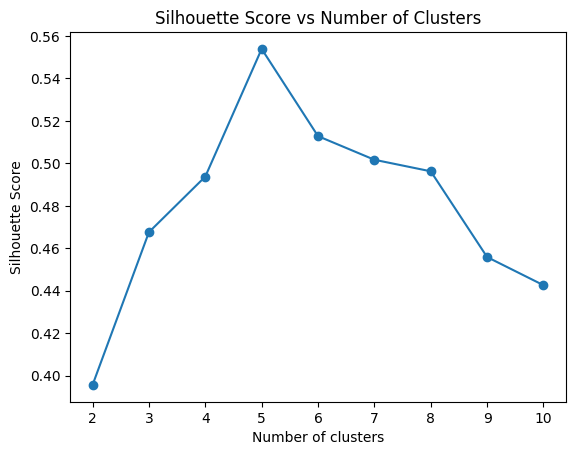

In [ ]:
plt.plot(range(2,11), silhouette_scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.show()

Silhouette Score ranges from -1 to +1

+1 → Well-separated clusters (best)

0 → Overlapping clusters

Negative → Wrong clustering